In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq

model = ChatGroq(model_name="qwen/qwen3-32b")

model.invoke("Hello, how are you?")

AIMessage(content='<think>\nOkay, so the user is asking "What is 2+2". That seems pretty straightforward, but maybe I should think through it carefully to make sure I don\'t miss anything. Let\'s start by recalling basic arithmetic. Addition is one of the fundamental operations in mathematics. The number 2 represents a quantity, so adding two of them together would be combining those quantities.\n\nIn the decimal system, which is what we commonly use, each digit represents a value based on its position. However, in this case, both numbers are single digits, so there\'s no need for carrying over or anything like that. The addition of 2 and 2 is just a simple sum. \n\nI remember from school that 2 + 2 equals 4. But maybe I should verify this. Let\'s count. If you have two apples and you add two more apples, how many apples do you have? The answer would be four apples. So that checks out. \n\nAnother way to think about it is using the number line. Starting at 2 and moving two units to the

In [7]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(
    max_results=5,
    topic="general"
)

{'query': 'What is the current AI news?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.artificialintelligence-news.com/',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
   'content': "US government increases AI suppliers and rethinks Anthropic's role · Google tests Remy AI agent for Gemini as focus turns to user control · Physical AI raises",
   'score': 0.6675167,
   'raw_content': None},
  {'url': 'https://www.wsj.com/tech/ai',
   'title': 'Artificial Intelligence - Latest AI News and Analysis - WSJ.com',
   'content': 'The latest artificial intelligence news coverage focusing on the technology, tools and the companies building AI technology.',
   'score': 0.6628188,
   'raw_content': None},
  {'url': 'https://www.reuters.com/technology/artificial-intelligence/',
   'title': 'AI News | Latest Headlines and Developments | Reuters',
   'content': 'Explore the latest artificial intelligence news with 

In [5]:
from langchain.tools import tool


@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

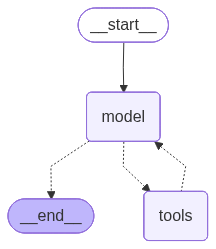

In [10]:
from langchain.agents import create_agent

agent = create_agent(model, tools=[calc, search_tool])

agent


In [11]:
user_input = "What is the current AI news for Anthropic and then calculate the sum of 10 and 20"

for step in agent.stream(
    {"messages": user_input},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current AI news for Anthropic and then calculate the sum of 10 and 20
================================== Ai Message ==================================
Tool Calls:
  tavily_search (a837fdys0)
 Call ID: a837fdys0
  Args:
    query: current AI news for Anthropic
    search_depth: basic
    time_range: week
    topic: news
  calculator (w9d2pa29r)
 Call ID: w9d2pa29r
  Args:
    expression: 10 + 20
================================= Tool Message =================================
Name: calculator

30
================================== Ai Message ==================================

Here's the information you requested:

**Current AI News for Anthropic (March 2026):**
1. **Model Context Protocol Milestone**: Anthropic's Model Context Protocol reached 97 million installs, transitioning from experimental to mainstream adoption.
2. **Financial Services Innovation**: Launched 10 new AI agents for financia

In [12]:
response = agent.invoke({"messages": user_input})

print(response.messages[-1].content)

{'messages': [HumanMessage(content='What is the current AI news for Anthropic and then calculate the sum of 10 and 20', additional_kwargs={}, response_metadata={}, id='50e448bc-bc4c-4fed-84ea-9a0057b46ea8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for two things: first, the current AI news about Anthropic, and second, to calculate the sum of 10 and 20. Let me break this down.\n\nFor the first part, I need to find recent news related to Anthropic in the AI field. The user mentioned "current AI news," so I should use the tavily_search tool. I\'ll need to set the query to "current AI news for Anthropic." Since they want the latest information, I should check if there\'s a time range parameter. The tool has a \'time_range\' parameter with options like day, week, month, year. The user didn\'t specify a specific time frame, but "current" usually implies recent, maybe within a week. So I\'ll set time_range to "week" to get the latest news from